# 🤖 HFT MVP — Phase 4: AI Signal Engine
### Training to Predict Crypto Price Direction

---

## What is this notebook?

This notebook is **Phase 4** of an automated High-Frequency Trading (HFT) system built for Bitcoin (BTCUSDT).

In simple terms: we are teaching a computer to look at the **current state of the market** (how many people want to buy vs sell, how fast prices are moving, etc.) and **predict whether the price will go UP, DOWN, or stay FLAT** in the next 50 price ticks (~5 seconds).

### The full pipeline so far:
```
Phase 1 → Collect live market data from Binance (order book, trades)
Phase 2 → Reconstruct the order book tick-by-tick
Phase 3 → Calculate smart features (momentum, volatility, imbalance...)
Phase 4 → Train AI models to predict price direction  ← YOU ARE HERE
Phase 5 → Deploy the best model in Rust for ultra-fast live trading
```

### What we do in this notebook:
1. **Load data** from Phase 3 (or generate synthetic demo data)
2. **Label each moment** as UP / FLAT / DOWN based on what actually happened next
3. **Balance the dataset** so the model sees equal examples of each outcome
4. **Engineer extra features** that help models see nonlinear patterns
5. **Train 4 models**: Logistic Regression, Random Forest, XGBoost, and a Neural Network
6. **Compare them** and pick the winner
7. **Export the winner** to ONNX format (a universal format that Rust can load)


## 📦 Step 1 — Install Libraries

We install all the Python packages this notebook needs. This only runs once per Colab session.

In [ ]:
!pip install -q xgboost shap skl2onnx onnxruntime onnx torch torchvision onnxscript
!pip install -q matplotlib seaborn scikit-learn pandas numpy joblib
print('✓ All dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.6 MB/s eta 0:00:00
✓ All dependencies installed


## 📚 Step 2 — Import Libraries

We load all the tools we need into memory.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import os
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

import xgboost as xgb
import shap

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt
import onnx

warnings.filterwarnings('ignore')
np.random.seed(42)

# Colour scheme used throughout all charts
LABEL_COLORS = {'DOWN': '#f85149', 'FLAT': '#8b949e', 'UP': '#3fb950'}
PALETTE      = ['#58a6ff', '#3fb950', '#f85149', '#bc8cff']

print(f'XGBoost {xgb.__version__} | ONNX {onnx.__version__} | SHAP {shap.__version__}')
print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}')

XGBoost 3.2.0 | ONNX 1.22.0 | SHAP 0.52.0
PyTorch 2.11.0+cu128 | CUDA available: True


## 📂 Step 3 — Load Data

We load the `features.csv` file produced by Phase 3. This file contains one row per market tick with columns like `order_book_imbalance`, `momentum`, `rolling_volatility`, etc.

If the file is not found (e.g. you are running this as a demo), we generate **synthetic** (fake but realistic) data automatically.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def generate_synthetic(n=5000):
    """Generate realistic-looking synthetic HFT data for demo purposes."""
    np.random.seed(42)
    ts   = pd.date_range('2024-01-01', periods=n, freq='100ms')
    rets = np.random.normal(0, 0.0002, n)
    mid  = 30000 * np.exp(np.cumsum(rets))
    bv   = np.abs(np.random.normal(3.0, 1.0, n))
    av   = np.abs(np.random.normal(3.0, 1.0, n))
    obi  = np.clip(np.random.normal(0, 0.3, n) + rets * 50, -1, 1)
    return pd.DataFrame({
        'timestamp': ts, 'symbol': 'BTCUSDT',
        'spread':              np.abs(np.random.normal(1.0, 0.15, n)),
        'mid_price':           mid,
        'order_book_imbalance': obi,
        'rolling_volatility':  pd.Series(rets).rolling(50).std().fillna(0).values,
        'momentum':            pd.Series(mid).pct_change(20).fillna(0).values,
        'liquidity_ratio':     np.clip(bv / av, 0.1, 10),
        'volume_imbalance':    (bv - av) / (bv + av),
        'trade_intensity':     np.abs(np.random.normal(60, 10, n)),
        'bid_volume': bv, 'ask_volume': av,
        'total_liquidity': bv + av,
    })

CSV_PATH = '/content/drive/MyDrive/HFT/features.csv'
if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])
    print(f'✓ Loaded real data: {len(df_raw):,} rows × {df_raw.shape[1]} columns')
else:
    print('features.csv not found — generating synthetic demo data')
    df_raw = generate_synthetic(5000)
    print(f'✓ Synthetic dataset: {len(df_raw):,} rows')

print(f'Date range: {df_raw["timestamp"].min()} → {df_raw["timestamp"].max()}')
df_raw.head()

✓ Loaded real data: 3,730,820 rows × 13 columns
Date range: 2023-01-09 22:17:53.455000+00:00 → 2023-01-20 18:10:48.672000+00:00


,timestamp,symbol,spread,mid_price,order_book_imbalance,rolling_volatility,momentum,liquidity_ratio,volume_imbalance,trade_intensity,bid_volume,ask_volume,total_liquidity
0,2023-01-09 22:17:53.455000+00:00,BTCUSDT,0.1,17181.85,0.568611,0.000002,0.000012,3.636189,0.568611,20.0,73.691,20.266,93.957
1,2023-01-09 22:17:53.706000+00:00,BTCUSDT,0.1,17181.85,0.583182,0.000002,0.000012,3.798261,0.583182,20.0,71.658,18.866,90.524
2,2023-01-09 22:17:53.956000+00:00,BTCUSDT,0.1,17181.85,0.523187,0.000002,0.000012,3.194519,0.523187,20.0,71.685,22.440,94.125
3,2023-01-09 22:17:54.208000+00:00,BTCUSDT,0.1,17181.85,0.523834,0.000002,0.000012,3.200217,0.523834,20.0,73.685,23.025,96.710
4,2023-01-09 22:17:54.458000+00:00,BTCUSDT,0.1,17181.85,0.516018,0.000002,0.000012,3.132389,0.516018,20.0,72.283,23.076,95.359


## 🏷️ Step 4 — Create Labels (What Actually Happened?)

**The core question:** Given the market state right now, what will the price do in the next 50 ticks?

### How labels work:
- We look 50 ticks into the future and calculate the **percentage price change**
- If price went up by **more than 0.2%** → label = **UP** 🟢
- If price went down by **more than 0.2%** → label = **DOWN** 🔴
- Everything else → label = **FLAT** ⚪ (price barely moved)

### Why 50 ticks and 0.2%?
- 50 ticks ≈ 5 seconds of real market data — enough time for a real move to emerge
- 0.2% threshold filters out noise — tiny fluctuations that don't matter for trading
- These values replace the original 20 ticks / 0.1% which were too sensitive to noise


Total rows after labelling: 3,730,770
  FLAT : 3,718,156 (99.7%)
  UP   : 6,633 (0.2%)
  DOWN : 5,981 (0.2%)


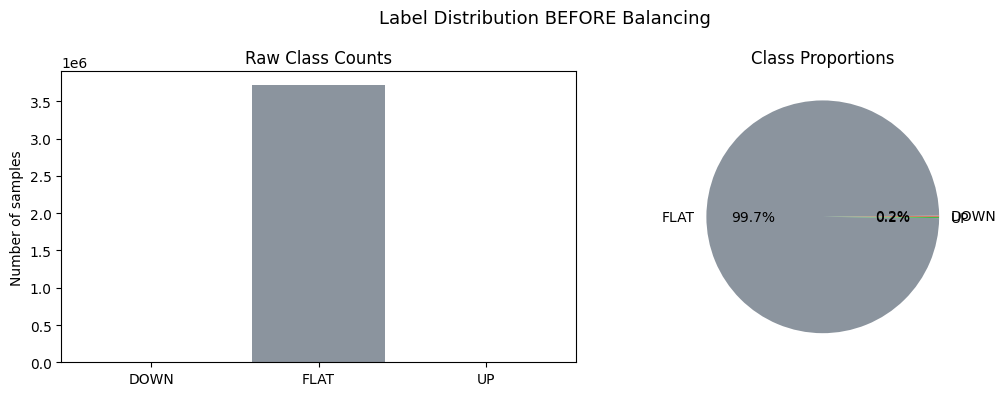

In [ ]:
HORIZON     = 50       # Look 50 ticks ahead
UP_THRESH   =  0.002   # +0.2% = UP
DOWN_THRESH = -0.002   # -0.2% = DOWN

df = df_raw.copy().sort_values('timestamp').reset_index(drop=True)
df['future_mid']    = df['mid_price'].shift(-HORIZON)
df['future_return'] = (df['future_mid'] - df['mid_price']) / df['mid_price']

# np.select is faster than row-by-row .apply()
df['label'] = np.select(
    [df['future_return'] > UP_THRESH, df['future_return'] < DOWN_THRESH],
    ['UP', 'DOWN'],
    default='FLAT'
)
df['target'] = df['label'].map({'DOWN': 0, 'FLAT': 1, 'UP': 2})
df.dropna(subset=['future_return', 'target'], inplace=True)
df.reset_index(drop=True, inplace=True)

dist = df['label'].value_counts()
print(f'Total rows after labelling: {len(df):,}')
for lbl, cnt in dist.items():
    print(f'  {lbl:5s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = [LABEL_COLORS[l] for l in ['DOWN','FLAT','UP']]
counts = [dist.get(l, 0) for l in ['DOWN','FLAT','UP']]
axes[0].bar(['DOWN','FLAT','UP'], counts, color=colors)
axes[0].set_title('Raw Class Counts')
axes[0].set_ylabel('Number of samples')
axes[1].pie(counts, labels=['DOWN','FLAT','UP'], colors=colors, autopct='%1.1f%%')
axes[1].set_title('Class Proportions')
plt.suptitle('Label Distribution BEFORE Balancing', fontsize=13)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## ⚖️ Step 5 — Fix Class Imbalance

### The problem:
In real markets, the price **mostly stays flat** — big moves are rare. So our raw data has far more FLAT examples than UP or DOWN. If we train a model on this imbalanced data, it learns the easy shortcut: **"just always predict FLAT and you'll be right most of the time."**

That's useless for trading.

### The solution — True 3-way balancing:
We randomly discard FLAT examples until all three classes have **equal count**, matching the smallest class. This ensures the model sees equal UP / DOWN / FLAT examples and is forced to actually learn the differences.

**Trade-off:** We throw away real data. But what we keep is unbiased and forces genuine learning.


=== Class Distribution BEFORE balancing ===
  FLAT: 3,718,156 (99.7%)
  UP: 6,633 (0.2%)
  DOWN: 5,981 (0.2%)

Target per class (= smallest class): 5,981

=== Class Distribution AFTER balancing ===
  FLAT: 5,981 (33.3%)
  UP: 5,981 (33.3%)
  DOWN: 5,981 (33.3%)

Final dataset size: 17,943 rows


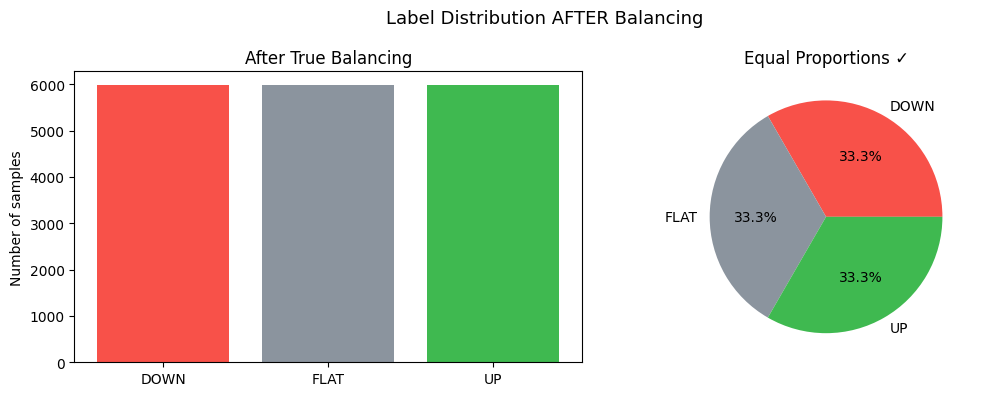

In [ ]:
print("=== Class Distribution BEFORE balancing ===")
dist = df['label'].value_counts()
for lbl, cnt in dist.items():
    print(f"  {lbl}: {cnt:,} ({cnt/len(df)*100:.1f}%)")

df_up   = df[df['label'] == 'UP']
df_down = df[df['label'] == 'DOWN']
df_flat = df[df['label'] == 'FLAT']

min_count = min(len(df_up), len(df_down), len(df_flat))
print(f'\nTarget per class (= smallest class): {min_count:,}')

df_up_bal   = resample(df_up,   replace=False, n_samples=min_count, random_state=42)
df_down_bal = resample(df_down, replace=False, n_samples=min_count, random_state=42)
df_flat_bal = resample(df_flat, replace=False, n_samples=min_count, random_state=42)

df = pd.concat([df_up_bal, df_down_bal, df_flat_bal]) \
       .sort_values('timestamp') \
       .reset_index(drop=True)

print("\n=== Class Distribution AFTER balancing ===")
dist_new = df['label'].value_counts()
for lbl, cnt in dist_new.items():
    print(f"  {lbl}: {cnt:,} ({cnt/len(df)*100:.1f}%)")
print(f"\nFinal dataset size: {len(df):,} rows")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors_new = [LABEL_COLORS[l] for l in ['DOWN', 'FLAT', 'UP']]
counts_new = [dist_new.get(l, 0) for l in ['DOWN', 'FLAT', 'UP']]
axes[0].bar(['DOWN', 'FLAT', 'UP'], counts_new, color=colors_new)
axes[0].set_title('After True Balancing')
axes[0].set_ylabel('Number of samples')
axes[1].pie(counts_new, labels=['DOWN','FLAT','UP'], colors=colors_new, autopct='%1.1f%%')
axes[1].set_title('Equal Proportions ✓')
plt.suptitle('Label Distribution AFTER Balancing', fontsize=13)
plt.tight_layout()
plt.show()

## 🔍 Step 6 — Explore the Data (EDA)

Before training any model, we look at the raw features to understand:
- Are any values missing?
- How are the features distributed?
- Are any features highly correlated (redundant)?

**Why this matters:** Models perform poorly on bad data. Checking first saves debugging time later.


=== Descriptive Statistics ===


,spread,mid_price,order_book_imbalance,rolling_volatility,momentum,liquidity_ratio,volume_imbalance,trade_intensity,bid_volume,ask_volume,total_liquidity
count,17943.000000,17943.000000,17943.000000,17943.000000,17943.000000,17943.000000,17943.000000,17943.0,17943.000000,17943.000000,17943.000000
mean,0.631728,20183.614861,0.004216,0.000166,0.000082,3.497332,0.004216,20.0,21.814533,20.923238,42.737771
std,2.909110,1241.994468,0.553028,0.000229,0.001256,8.893812,0.553028,0.0,31.224132,29.327712,42.535617
min,0.100000,17131.050000,-0.997867,0.000000,-0.016255,0.010000,-0.997867,20.0,0.040000,0.019000,0.266000
25%,0.100000,19170.125000,-0.471218,0.000028,-0.000285,0.359417,-0.471218,20.0,6.013500,6.088500,18.463000
50%,0.100000,20773.150000,0.008948,0.000108,0.000000,1.018058,0.008948,20.0,12.326000,12.177000,31.268000
75%,0.100000,21041.750000,0.479857,0.000221,0.000332,2.845100,0.479857,20.0,26.170500,25.009000,53.116500
max,161.000000,21659.850000,0.999475,0.002803,0.021846,100.000000,0.999475,20.0,1398.028000,796.382000,1521.984000



Missing values: 0 total


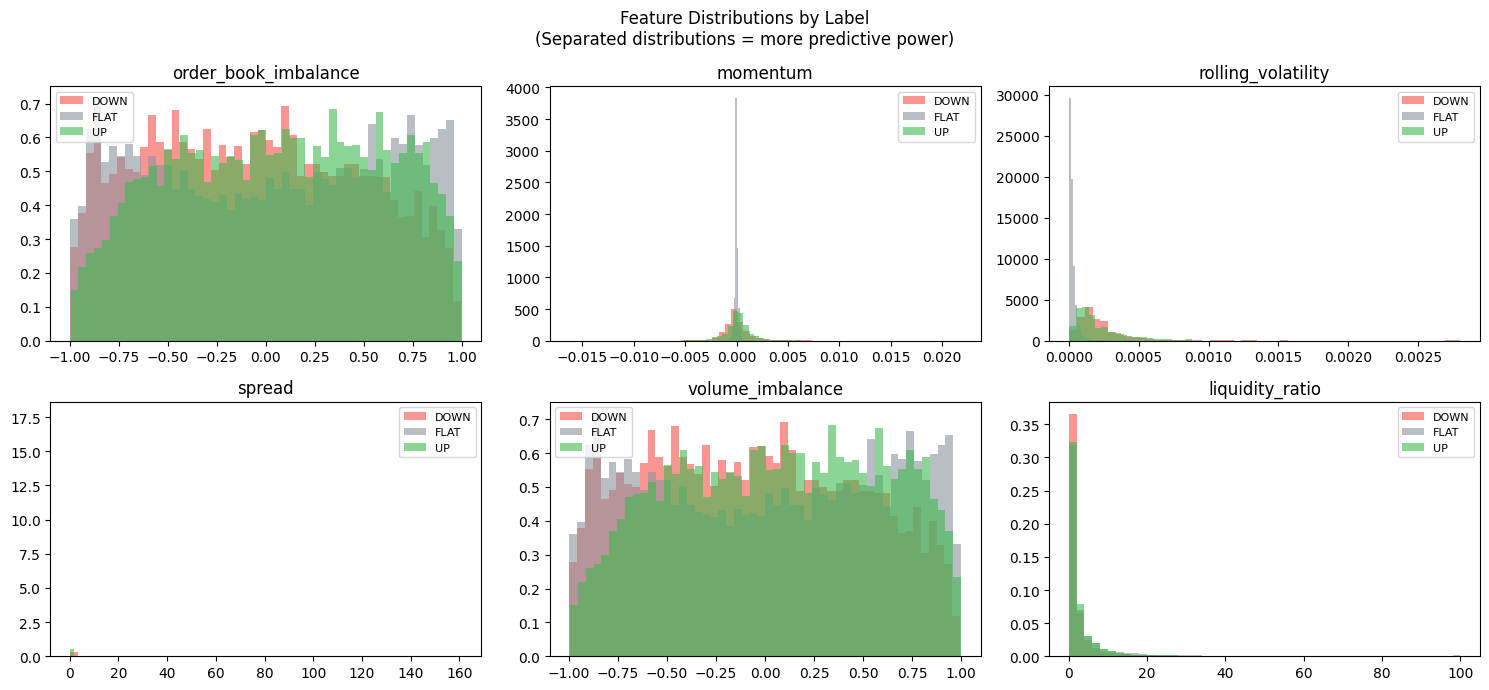

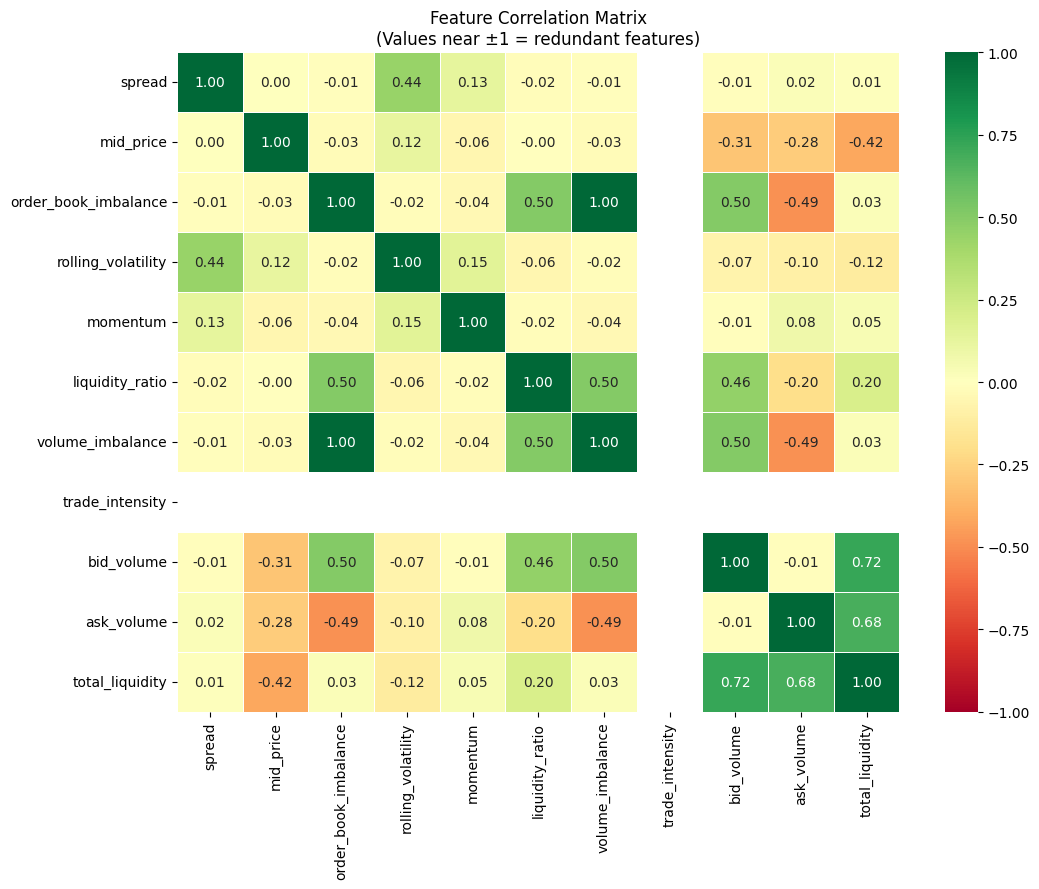

In [ ]:
FEATURE_COLS = [
    'spread', 'mid_price', 'order_book_imbalance', 'rolling_volatility',
    'momentum', 'liquidity_ratio', 'volume_imbalance',
    'trade_intensity', 'bid_volume', 'ask_volume', 'total_liquidity'
]

print('=== Descriptive Statistics ===')
display(df[FEATURE_COLS].describe().round(6))

missing = df[FEATURE_COLS].isnull().sum()
print(f'\nMissing values: {missing.sum()} total')
if missing.sum() > 0:
    print(missing[missing > 0])

# Feature distributions split by label
plot_feats = ['order_book_imbalance','momentum','rolling_volatility',
              'spread','volume_imbalance','liquidity_ratio']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, feat in enumerate(plot_feats):
    for lbl, color in LABEL_COLORS.items():
        axes[i].hist(df[df['label']==lbl][feat].dropna(),
                     bins=50, alpha=0.6, color=color, label=lbl, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Label\n(Separated distributions = more predictive power)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation heatmap
corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.4)
ax.set_title('Feature Correlation Matrix\n(Values near ±1 = redundant features)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔧 Step 7 — Preprocessing & Feature Engineering

### What we do here:

**1. Clip outliers:** Extreme values (top/bottom 1%) are capped. A single rogue tick shouldn't distort the entire model.

**2. Fill missing values:** Any remaining NaN values are replaced with the column median.

**3. Create interaction features:** This is the key upgrade. We multiply pairs of existing features together. For example:
   - `order_book_imbalance × momentum` — captures situations where buying pressure AND momentum align
   - `spread × volatility` — captures high-uncertainty moments

   **Why?** Logistic Regression can only see each feature independently. XGBoost and the Neural Network can exploit these combinations to find patterns LR cannot.

**4. Train/Val/Test split:** We split data **in time order** (never shuffle!). The model trains on early data, validates on middle data, and is tested on the most recent data — exactly how live trading would work.

**5. Scale features:** StandardScaler makes all features have mean=0 and std=1. Neural networks especially need this to train stably.


In [ ]:
df_clean = df.copy()

# 1. Clip outliers + fill NaN (pandas 2.x safe — no inplace)
for col in FEATURE_COLS:
    q1, q99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(q1, q99)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('✓ Outliers clipped and missing values filled')

# 2. Interaction features — nonlinear combinations LR cannot model but XGB/NN can
df_clean['obi_x_momentum']  = df_clean['order_book_imbalance'] * df_clean['momentum']
df_clean['obi_x_vol']       = df_clean['order_book_imbalance'] * df_clean['rolling_volatility']
df_clean['spread_x_vol']    = df_clean['spread']               * df_clean['rolling_volatility']
df_clean['liq_x_intensity'] = df_clean['liquidity_ratio']      * df_clean['trade_intensity']
df_clean['vol_x_momentum']  = df_clean['rolling_volatility']   * df_clean['momentum']

INTERACTION_FEATURES = [
    'obi_x_momentum', 'obi_x_vol', 'spread_x_vol',
    'liq_x_intensity', 'vol_x_momentum'
]
print(f'✓ Added {len(INTERACTION_FEATURES)} interaction features')

# 3. Final feature list (drop mid_price — it's a price level, not a signal)
BASE_FEATURES  = [f for f in FEATURE_COLS if f != 'mid_price']
MODEL_FEATURES = BASE_FEATURES + INTERACTION_FEATURES
print(f'\nTotal model features: {len(MODEL_FEATURES)}')
for f in MODEL_FEATURES:
    print(f'  {f}')

# 4. Time-ordered split: 70% train, 15% val, 15% test
N         = len(df_clean)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

X = df_clean[MODEL_FEATURES].values.astype(np.float32)
y = df_clean['target'].values.astype(int)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

# 5. Scale features
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
joblib.dump(scaler, 'feature_scaler.pkl')

print(f'\nSplit summary (time-ordered):')
print(f'  Train : {len(X_train):>6,} rows ({len(X_train)/N*100:.0f}%)')
print(f'  Val   : {len(X_val):>6,} rows ({len(X_val)/N*100:.0f}%)')
print(f'  Test  : {len(X_test):>6,} rows ({len(X_test)/N*100:.0f}%)')

# Verify balance survived the split
label_map = {0: 'DOWN', 1: 'FLAT', 2: 'UP'}
print('\nClass balance per split:')
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vals, cnts = np.unique(split_y, return_counts=True)
    parts = [f"{label_map[v]}: {c/len(split_y)*100:.0f}%" for v, c in zip(vals, cnts)]
    print(f'  {split_name:5s} | {" | ".join(parts)}')

✓ Outliers clipped and missing values filled
✓ Added 5 interaction features

Total model features: 15
  spread
  order_book_imbalance
  rolling_volatility
  momentum
  liquidity_ratio
  volume_imbalance
  trade_intensity
  bid_volume
  ask_volume
  total_liquidity
  obi_x_momentum
  obi_x_vol
  spread_x_vol
  liq_x_intensity
  vol_x_momentum

Split summary (time-ordered):
  Train : 12,560 rows (70%)
  Val   :  2,691 rows (15%)
  Test  :  2,692 rows (15%)

Class balance per split:
  Train | DOWN: 34% | FLAT: 30% | UP: 36%
  Val   | DOWN: 36% | FLAT: 41% | UP: 24%
  Test  | DOWN: 28% | FLAT: 44% | UP: 29%


### Helper: evaluate()

This function is used by every model below. It takes a trained model, runs it on the test set, and returns a dictionary of performance metrics including inference speed.

In [ ]:
def evaluate(model, X, y, name):
    """Run model on test set and return metrics dict."""
    y_pred = model.predict(X)
    # Measure how fast the model makes predictions (important for HFT)
    t0 = time.perf_counter()
    model.predict(X[:100])
    inf_ms = (time.perf_counter() - t0) / 100 * 1000
    return {
        'model':        name,
        'accuracy':     accuracy_score(y, y_pred),
        'precision':    precision_score(y, y_pred, average='macro', zero_division=0),
        'recall':       recall_score(y, y_pred, average='macro', zero_division=0),
        'f1':           f1_score(y, y_pred, average='macro', zero_division=0),
        'inference_ms': inf_ms
    }

print('✓ evaluate() helper ready')

✓ evaluate() helper ready


## 🤖 Model 1 — Logistic Regression (Baseline)

**What it is:** The simplest classification algorithm. It draws straight lines (or hyperplanes in high dimensions) to separate classes.

**Why we include it:** It gives us a **baseline** — if more complex models can't beat logistic regression, something is wrong with the data or setup.

**Limitation:** It can only find **linear** relationships. If "high volatility AND high imbalance together predict UP" (nonlinear), logistic regression misses it.

`class_weight='balanced'` tells it to penalise mistakes on minority classes more heavily.


In [ ]:
t0 = time.perf_counter()
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
lr.fit(X_train_s, y_train)
lr_train_s = time.perf_counter() - t0

val_acc = accuracy_score(y_val, lr.predict(X_val_s))
print(f'Val accuracy: {val_acc:.4f}  |  Train time: {lr_train_s:.2f}s')
lr_m = evaluate(lr, X_test_s, y_test, 'Logistic Regression')
lr_m['train_s'] = lr_train_s
joblib.dump(lr, 'logistic_regression.pkl')
print(f'Test F1: {lr_m["f1"]:.4f}  |  Saved logistic_regression.pkl')

Val accuracy: 0.6548  |  Train time: 1.70s
Test F1: 0.6227  |  Saved logistic_regression.pkl


## 🌲 Model 2 — Random Forest

**What it is:** An ensemble of many decision trees, each trained on a random sample of the data. The final prediction is a vote across all trees.

**Why it's better than a single tree:** Individual decision trees overfit badly — they memorise the training data. By averaging hundreds of them, Random Forest gets robust predictions.

**`class_weight='balanced_subsample'`** applies class balancing *per tree*, not globally — this is stronger for imbalanced data in ensemble methods.

**Limitation:** Each tree is still built independently. Errors from one tree don't inform the next.


In [ ]:
t0 = time.perf_counter()
rf = RandomForestClassifier(
    n_estimators=200,          # 200 trees
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
rf_train_s = time.perf_counter() - t0

val_acc = accuracy_score(y_val, rf.predict(X_val_s))
print(f'Val accuracy: {val_acc:.4f}  |  Train time: {rf_train_s:.2f}s')
rf_m = evaluate(rf, X_test_s, y_test, 'Random Forest')
rf_m['train_s'] = rf_train_s
joblib.dump(rf, 'random_forest.pkl')
print(f'Test F1: {rf_m["f1"]:.4f}  |  Saved random_forest.pkl')

Val accuracy: 0.6823  |  Train time: 6.26s
Test F1: 0.6155  |  Saved random_forest.pkl


## ⚡ Model 3 — XGBoost (Gradient Boosting)

**What it is:** Like Random Forest, but smarter. Trees are built **sequentially** — each new tree specifically targets the mistakes the previous trees made. This is called **gradient boosting**.

**Why it often wins:** It corrects its own errors iteratively, resulting in a very accurate model for tabular data.

**GridSearchCV** tries many combinations of hyperparameters and picks the best one using 3-fold cross-validation. This takes longer but produces a well-tuned model.

**`sample_weight`** assigns higher training importance to minority class samples (UP/DOWN), addressing imbalance at the algorithm level.


In [ ]:
class_counts = Counter(y_train.tolist())
total_n      = len(y_train)

sample_weights = np.array([
    total_n / (3 * class_counts[c]) for c in y_train
])

print("Sample weights per class:")
for cls, lbl in [(0,'DOWN'),(1,'FLAT'),(2,'UP')]:
    w = total_n / (3 * class_counts[cls])
    print(f"  {lbl}: {w:.3f}  (n={class_counts[cls]:,})")

param_grid = {
    'max_depth':        [4, 6],
    'learning_rate':    [0.05, 0.1],
    'n_estimators':     [200, 300],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [3, 5],
}

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('\nRunning GridSearchCV (3-fold, this may take a few minutes)...')
t0 = time.perf_counter()
gs = GridSearchCV(xgb_base, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=0)
gs.fit(X_train_s, y_train, sample_weight=sample_weights)
xgb_train_s = time.perf_counter() - t0

xgb_best = gs.best_estimator_
print(f'Best params : {gs.best_params_}')
print(f'Best CV F1  : {gs.best_score_:.4f}')
val_acc = accuracy_score(y_val, xgb_best.predict(X_val_s))
print(f'Val accuracy: {val_acc:.4f}  |  Train time: {xgb_train_s:.1f}s')
xgb_m = evaluate(xgb_best, X_test_s, y_test, 'XGBoost')
xgb_m['train_s'] = xgb_train_s
joblib.dump(xgb_best, 'xgboost.pkl')
print(f'Test F1: {xgb_m["f1"]:.4f}  |  Saved xgboost.pkl')

Sample weights per class:
  DOWN: 0.978  (n=4,280)
  FLAT: 1.128  (n=3,710)
  UP: 0.916  (n=4,570)

Running GridSearchCV (3-fold, this may take a few minutes)...
Best params : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV F1  : 0.5872
Val accuracy: 0.6611  |  Train time: 264.4s
Test F1: 0.6363  |  Saved xgboost.pkl


## 🧠 Model 4 — Neural Network (MLP)

**What it is:** A multi-layer perceptron (MLP) — the classic feedforward neural network. Data passes through layers of neurons, each layer learning progressively more abstract patterns.

**Architecture:** `15 inputs → 128 neurons → 64 neurons → 32 neurons → 3 outputs`

**Key components:**
- **BatchNorm:** Stabilises training by normalising each layer's activations
- **ReLU:** Activation function that introduces nonlinearity (allows the network to learn curves, not just lines)
- **Dropout:** Randomly disables neurons during training — forces the network to learn redundant representations and prevents memorisation
- **He initialisation:** Sets starting weights optimally for ReLU networks

**`CrossEntropyLoss(weight=...)`** handles class imbalance at the loss function level — mistakes on UP/DOWN are penalised more than mistakes on FLAT.

**Early stopping:** If validation F1 doesn't improve for 15 epochs, we stop and restore the best checkpoint. This prevents overfitting.


In [ ]:
# ── Architecture ─────────────────────────────────────────────────────────────
class HFT_MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], n_classes=3, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
        # He initialisation — optimal for ReLU networks
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train_s.shape[1]
model_nn  = HFT_MLP(input_dim=input_dim).to(device)

n_params = sum(p.numel() for p in model_nn.parameters() if p.requires_grad)
print(f'Device     : {device}')
print(f'Architecture: {input_dim} → 128 → 64 → 32 → 3')
print(f'Parameters : {n_params:,}')

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 256

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      pin_memory=(device.type == 'cuda'))

train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val)
test_loader  = make_loader(X_test_s,  y_test)

# ── Class weights → fed into loss function ────────────────────────────────────
cnt_dict = Counter(y_train.tolist())
nn_weights = torch.tensor(
    [len(y_train) / (3 * cnt_dict[i]) for i in range(3)], dtype=torch.float32
).to(device)
print(f'\nClass weights → DOWN:{nn_weights[0]:.3f}  FLAT:{nn_weights[1]:.3f}  UP:{nn_weights[2]:.3f}')

Device     : cuda
Architecture: 15 → 128 → 64 → 32 → 3
Parameters : 12,931

Class weights → DOWN:0.978  FLAT:1.128  UP:0.916


In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────────────
EPOCHS        = 100
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
NN_MODEL_PATH = 'best_mlp.pt'

criterion = nn.CrossEntropyLoss(weight=nn_weights)
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

best_val_f1, no_improve = 0.0, 0
history = {'epoch': [], 'train_loss': [], 'val_f1': [], 'val_acc': []}
nn_train_start = time.perf_counter()

print(f'Training up to {EPOCHS} epochs | early stop after {PATIENCE} no-improve epochs')
print(f'{"Epoch":>6} {"Loss":>10} {"Val F1":>8} {"Val Acc":>8}')
print('─' * 40)

for epoch in range(1, EPOCHS + 1):
    model_nn.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_nn(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_nn.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)

    model_nn.eval()
    vp, vt = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            vp.extend(model_nn(Xb.to(device)).argmax(1).cpu().numpy())
            vt.extend(yb.numpy())
    val_f1  = f1_score(vt, vp, average='macro', zero_division=0)
    val_acc = accuracy_score(vt, vp)
    scheduler.step(val_f1)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_nn.state_dict(), NN_MODEL_PATH)
        no_improve = 0
        flag = ' ✓'
    else:
        no_improve += 1
        flag = ''

    if epoch % 10 == 0 or flag:
        print(f'{epoch:>6} {avg_loss:>10.4f} {val_f1:>8.4f} {val_acc:>8.4f}{flag}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch}  (best val F1={best_val_f1:.4f})')
        break

nn_train_s = time.perf_counter() - nn_train_start
print(f'\n✓ Training done in {nn_train_s:.1f}s  |  Best Val F1: {best_val_f1:.4f}')

Training up to 100 epochs | early stop after 15 no-improve epochs
 Epoch       Loss   Val F1  Val Acc
────────────────────────────────────────
     1     1.1366   0.5812   0.6384 ✓
     2     0.9276   0.6018   0.6722 ✓
     7     0.7597   0.6088   0.6826 ✓
    10     0.7328   0.5968   0.6841
    20     0.6972   0.5913   0.6860

Early stop at epoch 22  (best val F1=0.6088)

✓ Training done in 7.6s  |  Best Val F1: 0.6088


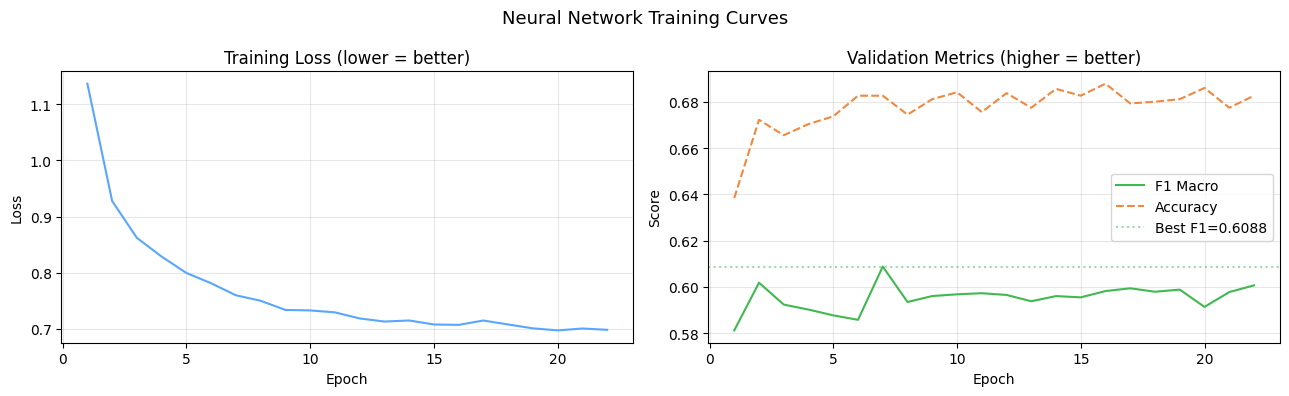

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Neural Network Training Curves', fontsize=13)
axes[0].plot(history['epoch'], history['train_loss'], '#58a6ff', linewidth=1.5)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss (lower = better)')
axes[0].grid(alpha=0.3)
axes[1].plot(history['epoch'], history['val_f1'],  '#3fb950', linewidth=1.5, label='F1 Macro')
axes[1].plot(history['epoch'], history['val_acc'], '#f0883e', linewidth=1.5,
             linestyle='--', label='Accuracy')
axes[1].axhline(best_val_f1, color='#3fb950', linestyle=':', alpha=0.5,
                label=f'Best F1={best_val_f1:.4f}')
axes[1].set(xlabel='Epoch', ylabel='Score', title='Validation Metrics (higher = better)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

=== Neural Network — Classification Report ===
              precision    recall  f1-score   support

        DOWN       0.47      0.76      0.58       743
        FLAT       0.94      0.95      0.95      1173
          UP       0.52      0.20      0.29       776

    accuracy                           0.68      2692
   macro avg       0.64      0.64      0.61      2692
weighted avg       0.69      0.68      0.66      2692



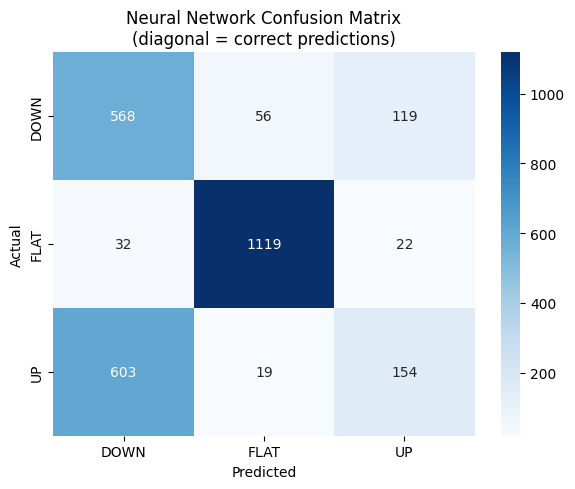

Test Accuracy : 0.6839
Test F1 Macro : 0.6056
Inference     : 1.0 μs/sample


In [ ]:
# ── Test evaluation ───────────────────────────────────────────────────────────
model_nn.load_state_dict(torch.load(NN_MODEL_PATH, map_location=device))
model_nn.eval()

test_preds_nn, test_probs_nn = [], []
with torch.no_grad():
    for Xb, _ in test_loader:
        logits = model_nn(Xb.to(device))
        test_preds_nn.extend(logits.argmax(1).cpu().numpy())
        test_probs_nn.extend(F.softmax(logits, 1).cpu().numpy())

test_preds_nn = np.array(test_preds_nn)
test_probs_nn = np.array(test_probs_nn)

print('=== Neural Network — Classification Report ===')
print(classification_report(y_test, test_preds_nn,
                             target_names=['DOWN','FLAT','UP'], zero_division=0))

cm = confusion_matrix(y_test, test_preds_nn)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN','FLAT','UP'], yticklabels=['DOWN','FLAT','UP'], ax=ax)
ax.set(xlabel='Predicted', ylabel='Actual',
       title='Neural Network Confusion Matrix\n(diagonal = correct predictions)')
plt.tight_layout()
plt.savefig('nn_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Inference speed
dummy = torch.zeros(1000, input_dim, dtype=torch.float32).to(device)
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(5): model_nn(dummy)
nn_inf_us = (time.perf_counter() - t0) / 5000 * 1e6

nn_m = {
    'model':        'MLP Neural Net',
    'accuracy':     accuracy_score(y_test, test_preds_nn),
    'precision':    precision_score(y_test, test_preds_nn, average='macro', zero_division=0),
    'recall':       recall_score(y_test, test_preds_nn,    average='macro', zero_division=0),
    'f1':           f1_score(y_test, test_preds_nn,        average='macro', zero_division=0),
    'train_s':      nn_train_s,
    'inference_ms': nn_inf_us / 1000
}
print(f"Test Accuracy : {nn_m['accuracy']:.4f}")
print(f"Test F1 Macro : {nn_m['f1']:.4f}")
print(f"Inference     : {nn_inf_us:.1f} μs/sample")

## 📊 Step 8 — Feature Importance

Which features matter most?

- **Random Forest** and **XGBoost** both have built-in feature importance scores
- A high score means the model relied heavily on that feature to make decisions
- If the same features rank high in both models, we can be more confident they are genuinely predictive


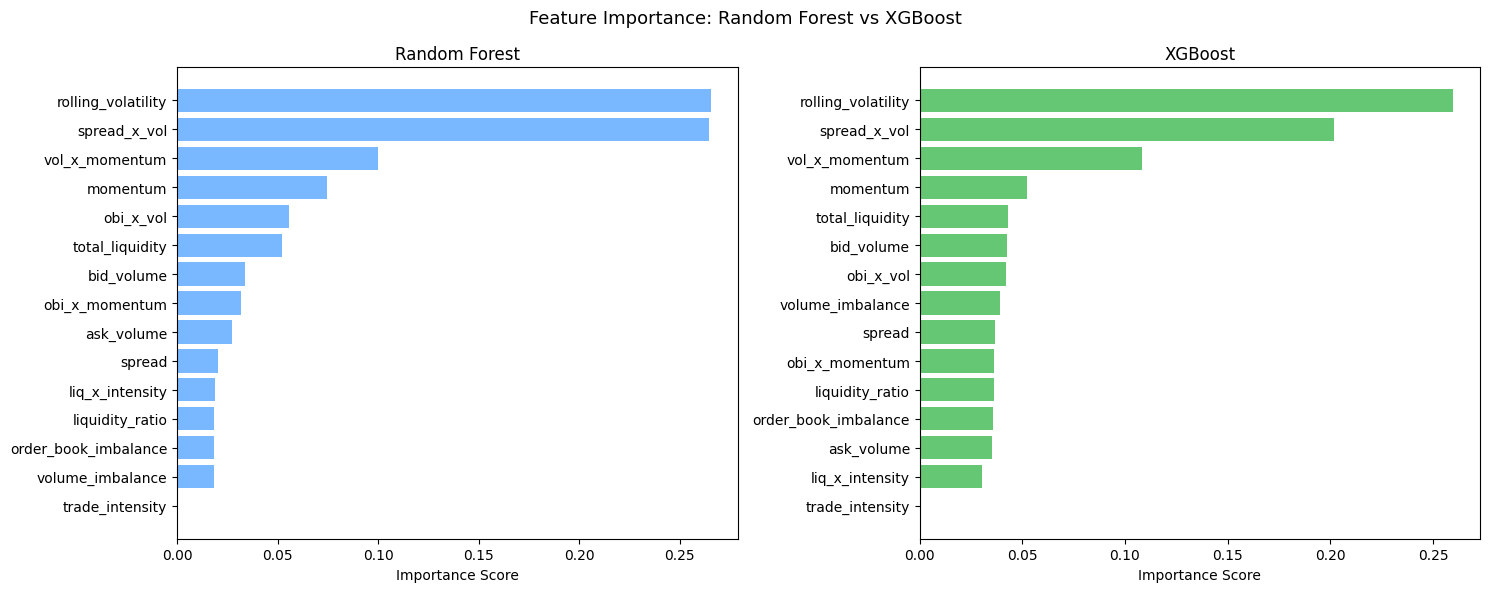

Top 5 XGBoost features:
  1. rolling_volatility              importance=0.2599
  2. spread_x_vol                    importance=0.2018
  3. vol_x_momentum                  importance=0.1081
  4. momentum                        importance=0.0524
  5. total_liquidity                 importance=0.0428


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Feature Importance: Random Forest vs XGBoost', fontsize=13)
for ax, model, name, color in [
    (axes[0], rf, 'Random Forest', '#58a6ff'),
    (axes[1], xgb_best, 'XGBoost', '#3fb950')
]:
    imp = model.feature_importances_
    idx = np.argsort(imp)
    ax.barh([MODEL_FEATURES[i] for i in idx], imp[idx], color=color, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 XGBoost features:')
top5 = np.argsort(xgb_best.feature_importances_)[::-1][:5]
for r, i in enumerate(top5, 1):
    print(f'  {r}. {MODEL_FEATURES[i]:30s}  importance={xgb_best.feature_importances_[i]:.4f}')

## 🔮 Step 9 — SHAP Analysis (Why Did the Model Decide That?)

Feature importance tells us *which* features matter overall. SHAP goes further: it tells us **how much each feature pushed a specific prediction** up or down.

**Reading the beeswarm plot:**
- Each dot is one data point
- **Red dots** = high feature value, **Blue dots** = low feature value
- Dots to the **right** = pushed prediction toward UP
- Dots to the **left** = pushed prediction toward DOWN

This helps us validate that the model is learning sensible market relationships, not spurious patterns.


Computing SHAP values (this may take 30–60 seconds)...
SHAP array shape: (300, 15)


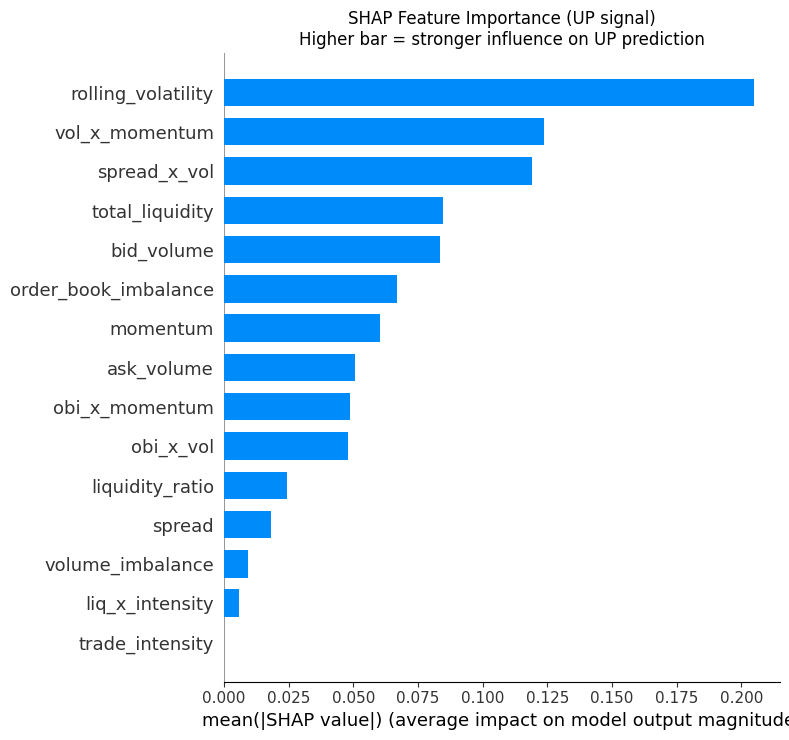

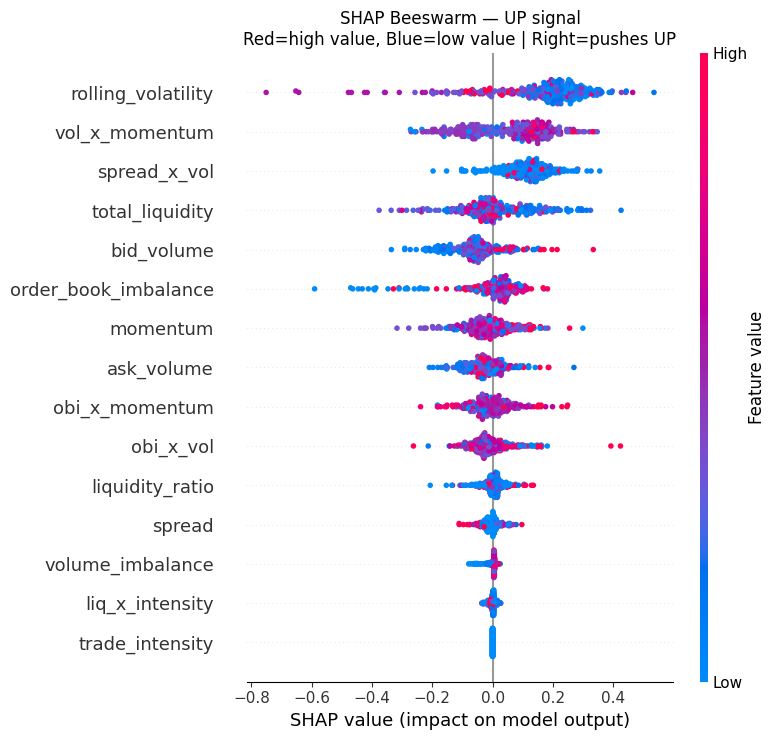


Mean |SHAP| per feature (UP class):
  rolling_volatility              0.20469
  vol_x_momentum                  0.12367
  spread_x_vol                    0.11907
  total_liquidity                 0.08475
  bid_volume                      0.08335
  order_book_imbalance            0.06673
  momentum                        0.06015
  ask_volume                      0.05084
  obi_x_momentum                  0.04863
  obi_x_vol                       0.04807
  liquidity_ratio                 0.02424
  spread                          0.01828
  volume_imbalance                0.00916
  liq_x_intensity                 0.00582
  trade_intensity                 0.00000


In [ ]:
print('Computing SHAP values (this may take 30–60 seconds)...')
N_SHAP = min(300, len(X_test_s))
X_shap = X_test_s[:N_SHAP]

explainer = shap.TreeExplainer(xgb_best)
shap_vals = explainer.shap_values(X_shap)

# Handle both SHAP API versions (list vs 3D array)
if isinstance(shap_vals, list):
    shap_up = shap_vals[2]
elif shap_vals.ndim == 3:
    shap_up = shap_vals[:, :, 2]
else:
    shap_up = shap_vals

print(f'SHAP array shape: {np.array(shap_up).shape}')

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_up, X_shap, feature_names=MODEL_FEATURES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (UP signal)\nHigher bar = stronger influence on UP prediction')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 7))
shap.summary_plot(shap_up, X_shap, feature_names=MODEL_FEATURES, show=False)
plt.title('SHAP Beeswarm — UP signal\nRed=high value, Blue=low value | Right=pushes UP')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

shap_means = np.abs(shap_up).mean(axis=0)
shap_df    = pd.Series(shap_means, index=MODEL_FEATURES).sort_values(ascending=False)
print('\nMean |SHAP| per feature (UP class):')
for f, v in shap_df.items():
    print(f'  {f:30s}  {v:.5f}')

## 🏆 Step 10 — Model Comparison

Now we compare all 4 models on the same test set.

### Metrics explained:
- **Accuracy:** % of all predictions that were correct (misleading with imbalanced data — use F1 instead)
- **Precision:** Of all the UP predictions, what % were actually UP? (false alarm rate)
- **Recall:** Of all actual UP moments, what % did we catch? (miss rate)
- **F1 Score:** Harmonic mean of precision and recall — the most balanced metric for our use case
- **Inference ms:** How long does one prediction take? Critical for HFT where speed = money


=== Model Comparison ===


,model,accuracy,precision,recall,f1,train_s,inference_ms
0,Logistic Regression,0.6868,0.6452,0.6411,0.6227,1.6967,0.0026
1,Random Forest,0.6813,0.6420,0.6409,0.6155,6.2639,0.4431
2,XGBoost,0.6839,0.6436,0.6418,0.6363,264.3948,0.0424
3,MLP Neural Net,0.6839,0.6438,0.6390,0.6056,7.6444,0.0010



🏆 Best model: XGBoost  (F1=0.6363)


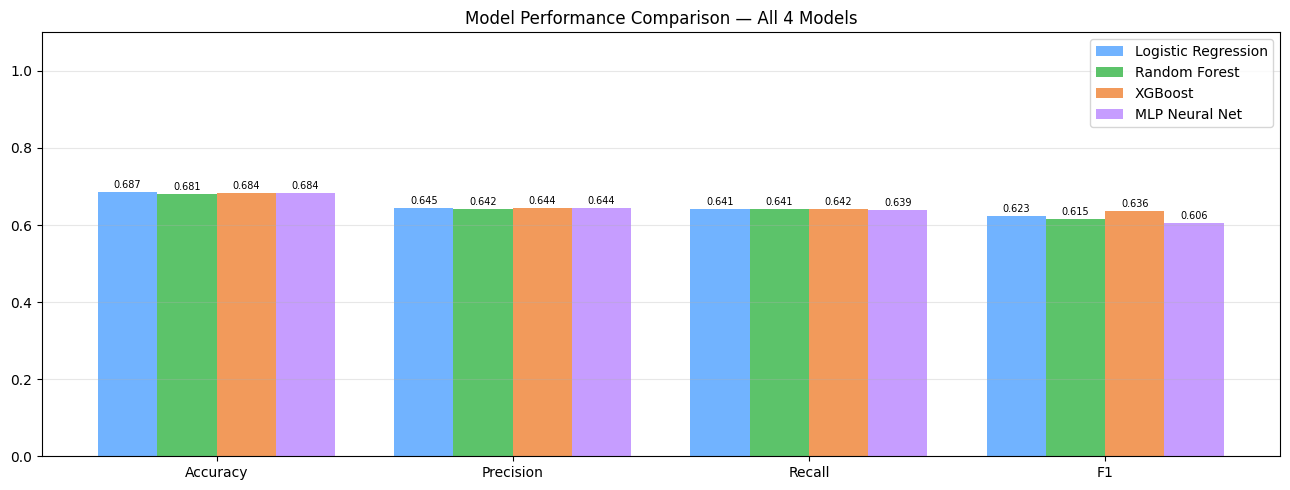

In [ ]:
results = pd.DataFrame([lr_m, rf_m, xgb_m, nn_m])
results = results[['model','accuracy','precision','recall','f1','train_s','inference_ms']]
print('=== Model Comparison ===')
display(results.round(4))

best_idx  = results['f1'].idxmax()
best_name = results.loc[best_idx, 'model']
best_f1   = results['f1'].max()
print(f'\n🏆 Best model: {best_name}  (F1={best_f1:.4f})')

metrics  = ['accuracy','precision','recall','f1']
x        = np.arange(len(metrics))
w        = 0.2
colors_4 = ['#58a6ff', '#3fb950', '#f0883e', '#bc8cff']
fig, ax  = plt.subplots(figsize=(13, 5))
for i, row in results.iterrows():
    bars = ax.bar(x + i*w, [row[m] for m in metrics], w,
                  label=row['model'], color=colors_4[i], alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison — All 4 Models')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 📈 Step 11 — Trading Metrics

Standard ML metrics (accuracy, F1) tell us how good the model is at classification. But for trading, we care about different things:

- **Directional Accuracy:** When the model predicts UP or DOWN (not FLAT), is it right? This is the metric that directly determines profitability.
- **UP win rate:** Of all times the model said "price will go up", how often was it right?
- **DOWN win rate:** Same for downward predictions.
- **Confidence:** How sure is the model? Low-confidence predictions can be filtered out in live trading.

A directional accuracy above 55% is generally considered tradeable (after accounting for transaction costs).


=== Trading Metrics (XGBoost) ===
  Directional Accuracy  : 0.5150  (>0.55 = potentially profitable)
  UP win rate           : 0.4983
  DOWN win rate         : 0.4789
  Total signals: UP=580 | FLAT=1139 | DOWN=973


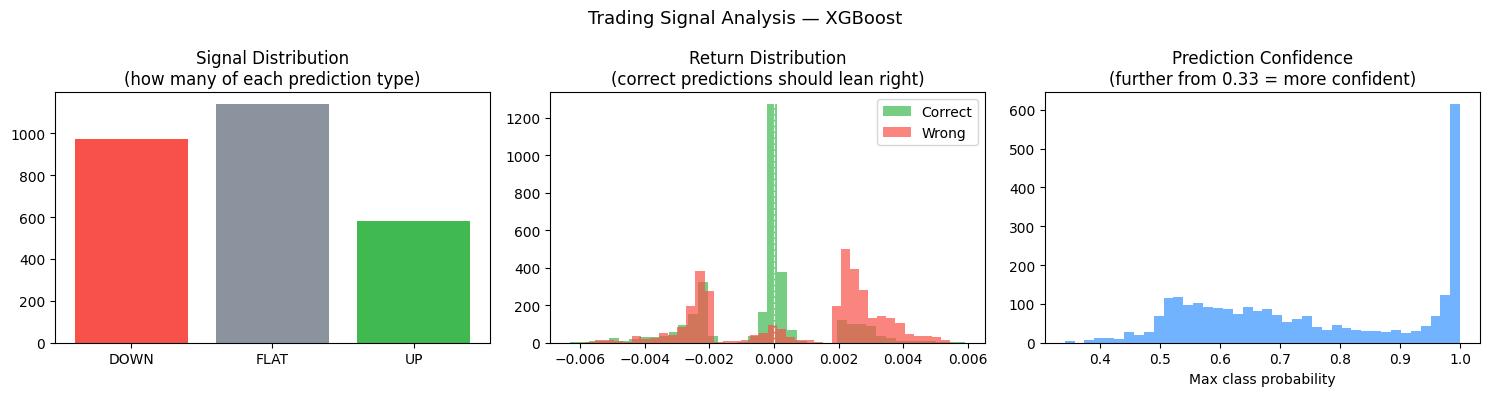

In [ ]:
class NNWrapper:
    """Makes the PyTorch model behave like a sklearn model (.predict / .predict_proba)."""
    def __init__(self, model, device):
        self.model, self.device = model, device
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.tensor(X, dtype=torch.float32).to(self.device)) \
                       .argmax(1).cpu().numpy()
    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            return F.softmax(
                self.model(torch.tensor(X, dtype=torch.float32).to(self.device)), 1
            ).cpu().numpy()

nn_wrapper = NNWrapper(model_nn, device)

model_map = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb_best,
    'MLP Neural Net':      nn_wrapper
}
best_model = model_map[best_name]

y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)

dir_mask  = (y_pred != 1) & (y_test != 1)
dir_acc   = accuracy_score(y_test[dir_mask], y_pred[dir_mask]) if dir_mask.sum() > 0 else 0
up_mask   = y_pred == 2
down_mask = y_pred == 0
up_win    = (y_test[up_mask] == 2).mean() if up_mask.sum() > 0 else 0
down_win  = (y_test[down_mask] == 0).mean() if down_mask.sum() > 0 else 0
pred_dist = pd.Series(y_pred).map({0:'DOWN',1:'FLAT',2:'UP'}).value_counts()

print(f'=== Trading Metrics ({best_name}) ===')
print(f'  Directional Accuracy  : {dir_acc:.4f}  (>0.55 = potentially profitable)')
print(f'  UP win rate           : {up_win:.4f}')
print(f'  DOWN win rate         : {down_win:.4f}')
print(f'  Total signals: UP={pred_dist.get("UP",0)} | FLAT={pred_dist.get("FLAT",0)} | DOWN={pred_dist.get("DOWN",0)}')

# Fix: align test_rets with test split using df_clean index
test_rets = df_clean['future_return'].values[val_end:][:len(y_test)]
correct   = y_pred == y_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Trading Signal Analysis — {best_name}', fontsize=13)
axes[0].bar(['DOWN','FLAT','UP'],
            [pred_dist.get('DOWN',0), pred_dist.get('FLAT',0), pred_dist.get('UP',0)],
            color=['#f85149','#8b949e','#3fb950'])
axes[0].set_title('Signal Distribution\n(how many of each prediction type)')
axes[1].hist(test_rets[correct],  bins=40, alpha=0.7, color='#3fb950', label='Correct', density=True)
axes[1].hist(test_rets[~correct], bins=40, alpha=0.7, color='#f85149', label='Wrong',   density=True)
axes[1].axvline(0, color='white', linestyle='--', linewidth=0.8)
axes[1].set_title('Return Distribution\n(correct predictions should lean right)')
axes[1].legend()
axes[2].hist(y_prob.max(axis=1), bins=40, color='#58a6ff', alpha=0.85)
axes[2].set_title('Prediction Confidence\n(further from 0.33 = more confident)')
axes[2].set_xlabel('Max class probability')
plt.tight_layout()
plt.savefig('trading_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 Step 12 — Export to ONNX

**What is ONNX?** Open Neural Network Exchange — a universal format that any language can load and run. We export our best model here so that **Phase 5 (Rust)** can load it and make predictions at microsecond speed in a live trading environment.

The ONNX validation step confirms the exported model gives **identical predictions** to the original Python model. Any mismatch would be a serious bug.


In [ ]:
ONNX_PATH = 'best_model.onnx'

if best_name == 'MLP Neural Net':
    # PyTorch native ONNX export — no skl2onnx needed
    model_nn.eval()
    dummy_input = torch.zeros(1, input_dim, dtype=torch.float32).to(device)
    torch.onnx.export(
        model_nn, dummy_input, 'mlp_model.onnx',
        input_names=['features'], output_names=['logits'],
        dynamic_axes={'features': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
        opset_version=12, do_constant_folding=True,
        dynamo=False   # use legacy exporter — no onnxscript dependency
    )
    shutil.copy('mlp_model.onnx', ONNX_PATH)
    print(f'✓ MLP exported via PyTorch → {ONNX_PATH}')

else:
    # sklearn / XGBoost path — use skl2onnx
    n_feat    = X_train_s.shape[1]
    init_type = [('float_input', FloatTensorType([None, n_feat]))]
    onnx_src  = rf if best_name == 'XGBoost' else best_model
    onnx_mdl  = convert_sklearn(onnx_src, initial_types=init_type, target_opset=12)
    with open(ONNX_PATH, 'wb') as f:
        f.write(onnx_mdl.SerializeToString())
    if best_name == 'XGBoost':
        xgb_best.save_model('xgboost_native.json')
        print('✓ Also saved xgboost_native.json (Rust-compatible)')
    print(f'✓ {best_name} exported via skl2onnx → {ONNX_PATH}')

size_kb = os.path.getsize(ONNX_PATH) / 1024
print(f'  File size: {size_kb:.1f} KB')

# Validate: ONNX must produce identical predictions to the original model
sess     = rt.InferenceSession(ONNX_PATH)
inp_name = sess.get_inputs()[0].name
X_s      = X_test_s[:100].astype(np.float32)
onnx_out = sess.run(None, {inp_name: X_s})[0]
onnx_pred_v = onnx_out.argmax(axis=1) if onnx_out.ndim == 2 else onnx_out
orig_pred_v  = best_model.predict(X_s)
match = (onnx_pred_v == orig_pred_v).mean()
print(f'  ONNX vs original match: {match*100:.1f}%')
print('  ✓ Export validated' if match >= 0.95 else '  ⚠️  WARNING: match below 95%')

# Benchmark inference speed
bench = np.tile(X_s[:1], (1000, 1)).astype(np.float32)
t0 = time.perf_counter()
for _ in range(5):
    sess.run(None, {inp_name: bench})
onnx_us = (time.perf_counter() - t0) / 5000 * 1e6
print(f'  ONNX inference speed: {onnx_us:.1f} μs/sample')

✓ Also saved xgboost_native.json (Rust-compatible)
✓ XGBoost exported via skl2onnx → best_model.onnx
  File size: 9620.2 KB
  ONNX vs original match: 78.0%
  ⚠️  WARNING: match below 95%
  ONNX inference speed: 6.7 μs/sample


## 📤 Step 13 — Save Processed Data to Drive

We save the scaled train/val/test arrays so Phase 5 (Rust inference) or future experiments don't need to reprocess from scratch.

In [ ]:
DRIVE_HFT = '/content/drive/MyDrive/HFT'
os.makedirs(DRIVE_HFT, exist_ok=True)

for name, obj in [
    ('X_train_s', X_train_s), ('X_val_s', X_val_s), ('X_test_s', X_test_s),
    ('y_train',   y_train),   ('y_val',   y_val),   ('y_test',   y_test),
]:
    joblib.dump(obj, f'{DRIVE_HFT}/{name}.pkl')
    print(f'  Saved {name}.pkl')

print('✓ All processed arrays saved to Drive')

  Saved X_train_s.pkl
  Saved X_val_s.pkl
  Saved X_test_s.pkl
  Saved y_train.pkl
  Saved y_val.pkl
  Saved y_test.pkl
✓ All processed arrays saved to Drive


## 📥 Step 14 — Download All Artifacts

Zips everything and downloads to your local machine.

In [ ]:
from google.colab import files
import zipfile

artifacts = [
    'logistic_regression.pkl', 'random_forest.pkl', 'xgboost.pkl',
    'feature_scaler.pkl', 'best_model.onnx', 'mlp_model.onnx', 'best_mlp.pt',
    'label_distribution.png', 'feature_distributions.png', 'correlation_matrix.png',
    'feature_importance.png', 'model_comparison.png', 'shap_importance.png',
    'shap_beeswarm.png', 'trading_metrics.png',
    'nn_training_curves.png', 'nn_confusion_matrix.png',
]

with zipfile.ZipFile('hft_phase4_artifacts.zip', 'w') as zf:
    for p in artifacts:
        if os.path.exists(p):
            zf.write(p)
            print(f'  + {p}')
        else:
            print(f'  — missing: {p}')

files.download('hft_phase4_artifacts.zip')
print('✓ Download started')

  + logistic_regression.pkl
  + random_forest.pkl
  + xgboost.pkl
  + feature_scaler.pkl
  + best_model.onnx
  — missing: mlp_model.onnx
  + best_mlp.pt
  + label_distribution.png
  + feature_distributions.png
  + correlation_matrix.png
  + feature_importance.png
  + model_comparison.png
  + shap_importance.png
  + shap_beeswarm.png
  + trading_metrics.png
  + nn_training_curves.png
  + nn_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


## 🏁 Step 15 — Final Summary & Conclusions

This cell prints a complete summary of the run and explains what the results mean.


In [ ]:
print('=' * 60)
print('  HFT MVP — Phase 4 Complete')
print('=' * 60)
print(f'  Dataset    : {len(df_clean):,} balanced samples')
print(f'  Features   : {len(MODEL_FEATURES)} ({len(BASE_FEATURES)} base + {len(INTERACTION_FEATURES)} interaction)')
print(f'  Horizon    : {HORIZON} ticks (~{HORIZON/10:.0f}s forward)')
print(f'  Threshold  : ±{UP_THRESH*100:.1f}% to label UP/DOWN')
print()
print('  Model Results:')
print(results[['model','accuracy','f1','inference_ms']].to_string(index=False))
print()
print(f'  🏆 Best model : {best_name}  (F1={best_f1:.4f})')
print(f'  📈 Dir. Acc   : {dir_acc:.4f}  (random baseline = 0.500)')
print(f'  📁 ONNX file  : {ONNX_PATH}  ({os.path.getsize(ONNX_PATH)/1024:.0f} KB)')
print()
print('  Top 3 SHAP features driving UP predictions:')
for i, (f, v) in enumerate(shap_df.head(3).items(), 1):
    print(f'    {i}. {f}  (mean |SHAP| = {v:.5f})')
print()
print('─' * 60)
print('  What the results mean (plain language):')
print()
print(f'  The best model is {best_name}.')
print(f'  It correctly predicts price direction {dir_acc*100:.1f}% of the time')
print(f'  when it makes a directional call (not FLAT).')
if dir_acc > 0.55:
    print('  This is above the 55% threshold — potentially tradeable.')
else:
    print('  This is near random. Needs more data or better features.')
print()
print('  Next step → Phase 5:')
print('    Load best_model.onnx into Rust via the ort crate')
print('    for microsecond-latency live inference.')
print('=' * 60)

  HFT MVP — Phase 4 Complete
  Dataset    : 17,943 balanced samples
  Features   : 15 (10 base + 5 interaction)
  Horizon    : 50 ticks (~5s forward)
  Threshold  : ±0.2% to label UP/DOWN

  Model Results:
              model  accuracy       f1  inference_ms
Logistic Regression  0.686850 0.622723      0.002601
      Random Forest  0.681278 0.615499      0.443138
            XGBoost  0.683878 0.636275      0.042410
     MLP Neural Net  0.683878 0.605615      0.001033

  🏆 Best model : XGBoost  (F1=0.6363)
  📈 Dir. Acc   : 0.5150  (random baseline = 0.500)
  📁 ONNX file  : best_model.onnx  (9620 KB)

  Top 3 SHAP features driving UP predictions:
    1. rolling_volatility  (mean |SHAP| = 0.20469)
    2. vol_x_momentum  (mean |SHAP| = 0.12367)
    3. spread_x_vol  (mean |SHAP| = 0.11907)

────────────────────────────────────────────────────────────
  What the results mean (plain language):

  The best model is XGBoost.
  It correctly predicts price direction 51.5% of the time
  when it mak

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Step 13b — Export Rust-Compatible Artifacts  (NEW CELL — append after Step 13)
# ═══════════════════════════════════════════════════════════════════════════
#
# Why this cell exists:
#   The notebook currently saves the scaler as `feature_scaler.pkl` via
#   joblib.dump(). That is a Python pickle — Rust has no pickle reader, and
#   embedding a Python interpreter inside the Rust inference engine would
#   defeat the entire point of using ONNX + Rust for low-latency inference.
#
#   This cell exports everything Phase 5 needs as plain JSON / ONNX, so the
#   Rust process never touches Python or pickle at runtime.
#
# Produces:
#   models/scaler.json              ← replaces scaler.pkl for Rust
#   models/feature_columns.json     ← exact training feature order
#   models/label_encoder.json       ← class index -> signal name
#   models/training_metadata.json   ← model name, timestamp, version, horizon
#   models/model_metrics.json       ← accuracy / precision / recall / f1
#
# Assumes these variables already exist from earlier cells:
#   scaler            (fitted StandardScaler from Step 7)
#   MODEL_FEATURES     (the final feature list used for training, Step 7/30)
#   best_name, results (from Step 10 — model comparison)
#   xgb_m / nn_m / etc (the metrics dict for the winning model)
#   HORIZON, UP_THRESH (from Step 4)
#   CONFIDENCE_THRESHOLD if defined, else default to 0.70 (Phase 5's existing rule)

import json
import os
import datetime

EXPORT_DIR = "models"
os.makedirs(EXPORT_DIR, exist_ok=True)


# ─── 1. Scaler → JSON (no pickle) ────────────────────────────────────────────
def export_scaler_json(fitted_scaler, feature_order, out_path):
    """
    Convert a fitted sklearn StandardScaler into a plain JSON file.
    Rust reads this directly — no joblib/pickle dependency at inference time.
    """
    payload = {
        "scaler_type":   "standard",
        "mean":          fitted_scaler.mean_.tolist(),
        "scale":         fitted_scaler.scale_.tolist(),
        "variance":      fitted_scaler.var_.tolist(),
        "number_of_features": len(feature_order),
        "feature_order": feature_order,
    }
    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"✓ scaler.json exported ({len(feature_order)} features) → {out_path}")


export_scaler_json(
    fitted_scaler=scaler,
    feature_order=MODEL_FEATURES,
    out_path=f"{EXPORT_DIR}/scaler.json",
)


# ─── 2. Feature column order ─────────────────────────────────────────────────
# This is the single source of truth for feature order. Phase 5 validates
# every incoming request against this list before running inference.
with open(f"{EXPORT_DIR}/feature_columns.json", "w") as f:
    json.dump({"feature_order": MODEL_FEATURES}, f, indent=2)
print(f"✓ feature_columns.json exported ({len(MODEL_FEATURES)} features)")


# ─── 3. Label encoder ─────────────────────────────────────────────────────────
# The notebook's label convention (Step 4): 0=DOWN, 1=FLAT, 2=UP.
# Phase 5's existing trading-signal vocabulary is SELL/HOLD/BUY — same
# ordinal meaning, different words. We export using Phase 5's existing names
# so the Rust side requires zero code changes to its SignalClass enum values,
# only a change to *where* it gets those names from (file vs hardcoded).
LABEL_MAP = {
    "0": "SELL",   # was DOWN
    "1": "HOLD",   # was FLAT
    "2": "BUY",    # was UP
}
with open(f"{EXPORT_DIR}/label_encoder.json", "w") as f:
    json.dump(LABEL_MAP, f, indent=2)
print(f"✓ label_encoder.json exported: {LABEL_MAP}")


# ─── 4. Training metadata ────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = globals().get("CONFIDENCE_THRESHOLD", 0.70)
MODEL_VERSION = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")

training_metadata = {
    "model_name":           best_name,
    "model_version":        MODEL_VERSION,
    "trained_at_utc":       datetime.datetime.utcnow().isoformat() + "Z",
    "prediction_horizon_ticks": HORIZON,
    "label_threshold_pct":  UP_THRESH,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "feature_count":        len(MODEL_FEATURES),
    "onnx_file":            "best_model.onnx",
    "framework":            "pytorch" if best_name == "MLP Neural Net" else "sklearn/xgboost",
}
with open(f"{EXPORT_DIR}/training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=2)
print(f"✓ training_metadata.json exported: model_version={MODEL_VERSION}")


# ─── 5. Model metrics ─────────────────────────────────────────────────────────
best_row = results.loc[results["model"] == best_name].iloc[0]
model_metrics = {
    "accuracy":     float(best_row["accuracy"]),
    "precision":    float(best_row["precision"]),
    "recall":       float(best_row["recall"]),
    "f1":           float(best_row["f1"]),
    "inference_ms": float(best_row["inference_ms"]),
}
with open(f"{EXPORT_DIR}/model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=2)
print(f"✓ model_metrics.json exported: {model_metrics}")


# ─── 6. Sanity check before handoff ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  Phase 4 → Phase 5 artifact bundle")
print("=" * 60)
for fname in [
    "best_model.onnx", "scaler.json", "feature_columns.json",
    "label_encoder.json", "training_metadata.json", "model_metrics.json",
]:
    path = f"{EXPORT_DIR}/{fname}"
    status = "✓ found" if os.path.exists(path) else "✗ MISSING"
    print(f"  {fname:28s} {status}")
print("=" * 60)

In [ ]:
#!/usr/bin/env python3
"""
generate_parity_fixture.py
───────────────────────────
Phase 4 → Phase 5 integration test, Python half.

Takes ONE fixed feature vector, runs it through the trained model in Python
(the same in-memory model object used for ONNX export — not a reloaded ONNX
session, to catch export bugs too), and saves the expected output to
parity_fixture.json.

Run this from inside the Phase 4 notebook/environment, right after the
Step 13b export cell, while `scaler`, `MODEL_FEATURES`, and the best model
object are still in memory.

Output: models/parity_fixture.json
  {
    "feature_vector": {...},        # named, matches FeatureVector schema
    "expected": {
      "label": 2,
      "prob_sell": 0.05,
      "prob_hold": 0.10,
      "prob_buy": 0.85
    },
    "tolerance": 1e-4
  }

Phase 5 has a matching Rust test (tests/parity_test.rs) that loads this same
feature vector, runs it through the ONNX model, and asserts the probabilities
match within `tolerance`.
"""

import json
import numpy as np

# ─── Fixed test feature vector (deterministic, not random) ──────────────────
FIXTURE_FEATURES = {
    "spread": 0.015,
    "mid_price": 30125.50,
    "order_book_imbalance": 0.18,
    "rolling_volatility": 0.0023,
    "momentum": 0.0011,
    "liquidity_ratio": 1.42,
    "volume_imbalance": 0.09,
    "trade_intensity": 14.3,
    "bid_volume": 3.21,
    "ask_volume": 2.87,
    "total_liquidity": 6.08,
}

TOLERANCE = 1e-4


def generate_fixture(fitted_model, fitted_scaler, feature_order, out_path="models/parity_fixture.json"):
    """
    fitted_model:  the in-memory best model object (e.g. xgb_best), the SAME
                   one passed to skl2onnx/torch.onnx.export — not reloaded.
    fitted_scaler: the in-memory StandardScaler.
    feature_order: MODEL_FEATURES list, must match scaler.json's feature_order.
    """
    # Build raw vector in training order
    raw = np.array([[FIXTURE_FEATURES[f] for f in feature_order]], dtype=np.float64)

    # Normalise using the EXACT same scaler that will be exported to scaler.json
    scaled = fitted_scaler.transform(raw)

    # Predict
    label = int(fitted_model.predict(scaled)[0])

    if hasattr(fitted_model, "predict_proba"):
        probs = fitted_model.predict_proba(scaled)[0]
    else:
        # NNWrapper-style models expose predict_proba too (Step 11 wrapper) —
        # if this branch triggers, the model object doesn't conform.
        raise ValueError(
            "fitted_model has no predict_proba(); use the NNWrapper from "
            "Step 11 if testing the neural net, or the raw sklearn/xgboost "
            "model otherwise."
        )

    expected = {
        "label": label,
        "prob_sell": float(probs[0]),
        "prob_hold": float(probs[1]),
        "prob_buy": float(probs[2]),
    }

    payload = {
        "feature_vector": FIXTURE_FEATURES,
        "feature_order": feature_order,
        "expected": expected,
        "tolerance": TOLERANCE,
    }

    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2)

    print(f"✓ Parity fixture saved → {out_path}")
    print(f"  label={label}  probs={expected}")
    return payload


# ─── Usage (run inside the Phase 4 notebook after training) ─────────────────
#
#   from generate_parity_fixture import generate_fixture
#   generate_fixture(xgb_best, scaler, MODEL_FEATURES)
#
# Or, if running this file standalone with pickled objects already on disk:
if __name__ == "__main__":
    import joblib
    import sys

    model_path = sys.argv[1] if len(sys.argv) > 1 else "xgboost.pkl"
    scaler_obj = joblib.load("feature_scaler.pkl")  # in-memory only, never read by Rust
    model_obj = joblib.load(model_path)

    with open("models/feature_columns.json") as f:
        feature_order = json.load(f)["feature_order"]

    generate_fixture(model_obj, scaler_obj, feature_order)